<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_6_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

# Capitolo 6, Regressione Lineare Multipla

In questo notebook estendiamo la regressione lineare a più variabili.  
Nel capitolo precedente avevamo una sola feature e una retta. Qui lavoriamo con **n feature**, vettori e matrici.

Tutto quello che abbiamo visto rimane valido: stessa funzione di costo, stessa discesa del gradiente, stessa logica.  
Cambia la notazione, diventa vettoriale, e questo ci apre le porte alla **vettorizzazione**, che rende il codice enormemente più veloce.

Seguiremo questa sequenza:

```
1. Il modello con n feature
2. Vettorizzazione: perché è fondamentale
3. La funzione di costo
4. Discesa del Gradiente con più variabili
5. Implementazione da zero con NumPy
6. Implementazione con scikit-learn
```

## 0. Setup, importare le librerie

In [25]:
%pip install numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import time

np.random.seed(42)
print('Setup completato!')

Setup completato!


## 1. Il modello con n feature

Con **n feature** il modello diventa:

```
f(x) = w · x + b
```

Il simbolo `·` è il **prodotto scalare**: somma dei prodotti elemento per elemento.  
Il risultato è identico alla formula esplicita, ma scritto in modo compatto.

Costruiamo un dataset sintetico per prevedere il **prezzo di un appartamento** a partire da tre feature:
- `X_1` = superficie in mq
- `X_2` = numero di stanze
- `X_3` = età dell'immobile (anni)

In [27]:
# Dataset sintetico: 100 appartamenti, 3 feature
m = 100 # numero di esempi
n = 3 # numero di feature

# X ha dimensione (m x n): ogni riga è un appartamento, ogni colonna è una feature
X = np.column_stack([
    np.random.uniform(40, 150, m), # x1: superficie (mq)
    np.random.randint(1, 6, m), # x2: numero di stanze
    np.random.randint(0, 40, m), # x3: età in anni
])

# Il prezzo vero segue questa relazione (che il modello dovrà imparare):
# prezzo = 2000 * mq + 5000 * stanze - 300 * età + 50000 + rumore
w_veri  = np.array([2000, 5000, -300])
b_vero  = 50_000
rumore  = np.random.randn(m) * 8_000
y       = X @ w_veri + b_vero + rumore

print(f'Dimensione di X: {X.shape} -> {m} esempi, {n} feature')
print(f'Dimensione di y: {y.shape} -> {m} prezzi target')
print()
print('Prime 5 righe di X (superficie | stanze | età):')
print(X[:5].astype(int))
print()
print('Primi 5 prezzi reali (€):')
print(y[:5].round(0).astype(int))

Dimensione di X: (100, 3) -> 100 esempi, 3 feature
Dimensione di y: (100,) -> 100 prezzi target

Prime 5 righe di X (superficie | stanze | età):
[[ 81   1  24]
 [144   4  22]
 [120   5  30]
 [105   4  29]
 [ 57   5  34]]

Primi 5 prezzi reali (€):
[217178 361087 299367 284061 186365]


Verifichiamo la notazione vista nel capitolo: come si accede a un singolo valore `x_j^(i)`?

In [ ]:
# Notazione: x^(i) e x_j^(i)
# NB: Python usa indici che partono da 0, ma la notazione matematica da 1

# x^(5) -> vettore di tutte le feature del 5° appartamento (indice 4 in Python)
x_5 = X[4]
print(f'x^(5) (vettore del 5° esempio): {x_5.astype(int)}')
print(f'superficie = {x_5[0]:.0f} mq')
print(f'stanze = {x_5[1]:.0f}')
print(f'età = {x_5[2]:.0f} anni')
print()

# X_2^(5) -> la seconda feature (stanze) del 5° appartamento
x2_5 = X[4, 1]
print(f'X_2^(5) (stanze del 5° esempio): {x2_5:.0f}')
print()

# Previsione manuale con i pesi veri (per verifica)
w_test = np.array([2000, 5000, -300])
b_test = 50_000
f_x5   = np.dot(w_test, x_5) + b_test
print(f'Previsione manuale per il 5° esempio: {f_x5:,.0f} €')
print(f'Prezzo reale del 5° esempio: {y[4]:,.0f} € (la differenza è il rumore)')

x^(5) (vettore del 5° esempio): [57  5 34]
superficie = 57 mq
stanze = 5
età = 34 anni

X_2^(5) (stanze del 5° esempio): 5

Previsione manuale per il 5° esempio: 179,124 €
Prezzo reale del 5° esempio: 186,365 € (la differenza è il rumore)


## 2. Vettorizzazione

La vettorizzazione è la tecnica di scrivere operazioni su interi vettori e matrici invece di usare cicli `for` espliciti.

Due motivi per usarla sempre:
1. **Leggibilità**: il codice è più corto e più vicino alla matematica
2. **Velocità**: NumPy usa operazioni ottimizzate in C e sfrutta le istruzioni SIMD del processore, che eseguono molti calcoli in parallelo

Vediamo prima la differenza su un singolo esempio, poi su tutti gli `m` esempi insieme.

### 2.1 Previsione su un singolo esempio

In [29]:
# Prendiamo il primo esempio e usiamo i pesi veri per la dimostrazione
x_esempio = X[0]
w = w_veri.astype(float)
b = float(b_vero)

# Senza vettorizzazione: ciclo for esplicito
f_loop = 0.0
for j in range(n):
    f_loop += w[j] * x_esempio[j]
f_loop += b

# Con vettorizzazione: una sola riga
# np.dot(w, x) calcola il prodotto scalare w_1X_1 + w_2X_2 + ... + w_nX_n
f_vett = np.dot(w, x_esempio) + b

print(f'Risultato con ciclo for: {f_loop:,.0f} €')
print(f'Risultato con np.dot(): {f_vett:,.0f} €')
print(f'Identici? {np.isclose(f_loop, f_vett)}')

Risultato con ciclo for: 210,199 €
Risultato con np.dot(): 210,199 €
Identici? True


### 2.2 Previsione su tutti gli m esempi

Qui la vettorizzazione fa la vera differenza.  
`X` è la matrice `(m × n)`: ogni riga è un esempio, ogni colonna è una feature.  
Con una sola operazione matriciale otteniamo un vettore di `m` previsioni.

In [ ]:
# Senza vettorizzazione: ciclo su tutti gli esempi
def predict_loop(X, w, b):
    m = X.shape[0]
    predictions = np.zeros(m)
    for i in range(m):
        for j in range(n):
            predictions[i] += w[j] * X[i, j]
        predictions[i] += b
    return predictions

# Con vettorizzazione: un'unica operazione matriciale
# X @ w è il prodotto matrice-vettore: restituisce direttamente il vettore delle m previsioni
# X ha dimensione (m x n), w ha dimensione (n,) -> risultato: vettore (m,)
def predict_vett(X, w, b):
    return X @ w + b   # equivalente a np.dot(X, w) + b

# Confronto di velocità su 100.000 esempi
m_grande  = 100_000
n_grande  = 50
X_grande  = np.random.rand(m_grande, n_grande)
w_grande  = np.random.rand(n_grande)
b_grande  = 1.0

t0 = time.time()
_ = predict_loop(X_grande, w_grande, b_grande)
t_loop = time.time() - t0

t0 = time.time()
_ = predict_vett(X_grande, w_grande, b_grande)
t_vett = time.time() - t0

print(f'Ciclo for: {t_loop:.3f} secondi')
print(f'Vettorizzato: {t_vett:.4f} secondi')
print(f'Speedup: {t_loop / t_vett:.0f}x più veloce')

Ciclo for: 0.129 secondi
Vettorizzato: 0.0082 secondi
Speedup: 16x più veloce


## 3. La funzione di costo

Come scritto nel libro, la funzione di costo è identica a quella con una sola variabile.  
L'unica differenza è che `f(x^(i))` ora usa il prodotto scalare invece di `wx + b`:

```
J(w, b) = (1/2m) * Σ (f(x⁽ⁱ⁾) - y⁽ⁱ⁾)²
```

dove `f(x^(i)) = w · x⁽ⁱ⁾ + b`.

L'obiettivo rimane lo stesso: trovare `w` e `b` che minimizzano `J`.

In [31]:
def compute_cost(X, y, w, b):
    """
    Calcola J(w, b) = (1/2m) * sum((Xw + b - y)²)
    
    X: matrice (m x n)
    y: vettore target (m,)
    w: vettore dei pesi (n,)
    b: bias scalare
    """
    m = X.shape[0]
    # predictions è il vettore delle m previsioni (vettorizzato)
    predictions = X @ w + b
    # errors è il vettore degli m errori
    errors = predictions - y
    # Costo: media dei quadrati degli errori, diviso per 2
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# Con i pesi veri il costo deve essere molto basso (solo il rumore lo alza)
J_veri = compute_cost(X, y, w_veri.astype(float), float(b_vero))
# Con pesi sbagliati il costo deve essere molto più alto
J_sbagliati = compute_cost(X, y, np.zeros(n), 0.0)

print(f'J con pesi veri (w={w_veri}, b={b_vero}): {J_veri:,.0f}')
print(f'J con pesi a zero (w=[0,0,0], b=0): {J_sbagliati:,.0f}')


J con pesi veri (w=[2000 5000 -300], b=50000): 34,006,085
J con pesi a zero (w=[0,0,0], b=0): 31,730,886,590


## 4. Discesa del Gradiente con più variabili

La logica è identica a quella con una sola variabile: si calcola la derivata parziale di `J` rispetto a ogni parametro e si aggiornano tutti **simultaneamente**.

La differenza è che ora bisogna aggiornare `n` pesi `w₁, w₂, ..., wₙ` oltre al bias `b`.

In forma vettorizzata:
```
predictions = X @ w + b # vettore di m previsioni
errors = predictions - y  # vettore di m errori
dw = (1/m) * X^T @ errors # gradiente per tutti i wj insieme
db = (1/m) * sum(errors) # gradiente per b
w  = w - α * dw
b  = b - α * db
```

Con `X^T @ errors` in una sola operazione calcoliamo i gradienti per tutte le `n` feature contemporaneamente.

In [32]:
def gradient_descent(X, y, alpha=0.01, epochs=1000):
    """
    Discesa del gradiente vettorizzata per la regressione lineare multipla.
    
    X: matrice delle feature (m x n)
    y: vettore target (m,)
    alpha:  learning rate
    epochs: numero di iterazioni
    
    Restituisce: w ottimali (n,), b ottimale, storia dei costi
    """
    m, n = X.shape
    
    # Inizializzazione a zero: punto di partenza arbitrario
    w = np.zeros(n)
    b = 0.0
    
    cost_history = []
    
    for epoch in range(epochs):
        # 1. Previsioni: vettore di m valori
        predictions = X @ w + b
        
        # 2. Errori: differenza tra previsto e reale
        errors = predictions - y
        
        # 3. Gradienti (vettorizzati)
        # X.T @ errors: per ogni peso wj, somma errors[i] * xj[i] su tutti gli m esempi
        dw = (1 / m) * X.T @ errors   # vettore (n,)
        db = (1 / m) * np.sum(errors)  # scalare
        
        # 4. Aggiornamento simultaneo (CORRETTO)
        # temp_w e temp_b calcolati con i vecchi valori, poi applicati insieme
        w = w - alpha * dw
        b = b - alpha * db
        
        # Salviamo il costo ogni 100 iterazioni per non rallentare il loop
        if epoch % 100 == 0:
            cost_history.append(compute_cost(X, y, w, b))
    
    return w, b, cost_history

print('Funzione gradient_descent definita.')
print('X.T ha dimensione:', X.T.shape, '  (n x m)')

Funzione gradient_descent definita.
X.T ha dimensione: (3, 100)   (n x m)


## 5. Implementazione da zero con NumPy

Prima eseguiamo la discesa del gradiente e osserviamo la curva di apprendimento.  
Poi confrontiamo i pesi trovati con quelli veri.

> **NB sul feature scaling**: con feature su scale molto diverse (mq vs numero di stanze vs anni), la discesa del gradiente converge lentamente. Qui usiamo un learning rate piccolo per compensare; nel capitolo successivo vedremo il feature scaling che risolve il problema alla radice.

In [33]:
# Addestriamo il modello con gradient descent
# NB: il learning rate è piccolo perché le feature non sono scalate
w_fit, b_fit, cost_history = gradient_descent(X, y, alpha=1e-5, epochs=10000)

print('Confronto pesi trovati vs pesi veri:')
print(f'{"Feature":<12} {"Trovato":>12} {"Vero":>12}')
feature_names = ['superficie', 'stanze', 'età']
for i, nome in enumerate(feature_names):
    print(f'{nome:<12} {w_fit[i]:>12.1f} {w_veri[i]:>12.1f}')
print(f'{"bias b":<12} {b_fit:>12.1f} {b_vero:>12.1f}')
print()
print(f'Costo finale: {compute_cost(X, y, w_fit, b_fit):,.0f}')

Confronto pesi trovati vs pesi veri:
Feature           Trovato         Vero
superficie         2438.1       2000.0
stanze             2042.0       5000.0
età                 364.3       -300.0
bias b              500.9      50000.0

Costo finale: 170,854,559


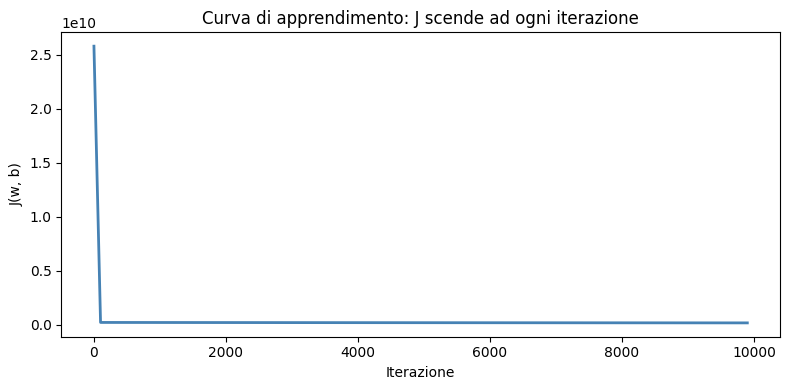

La curva scende rapidamente all'inizio, poi rallenta man mano che ci avvicina al minimo.
Questa forma a gomito è tipica della discesa del gradiente.


In [34]:
# Curva di apprendimento: J deve scendere monotonicamente
# Se J sale o oscilla, il learning rate è troppo grande

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(cost_history)) * 100, cost_history, color='steelblue', linewidth=2)
plt.xlabel('Iterazione')
plt.ylabel('J(w, b)')
plt.title('Curva di apprendimento: J scende ad ogni iterazione')
plt.tight_layout()
plt.show()

print('La curva scende rapidamente all\'inizio, poi rallenta man mano che ci avvicina al minimo.')
print('Questa forma a gomito è tipica della discesa del gradiente.')

### 5.1 Previsioni con il modello addestrato

Usiamo i pesi trovati dalla discesa del gradiente per fare previsioni su nuovi appartamenti.

In [35]:
# Nuovi appartamenti da valutare
# Ogni riga: [superficie (mq), stanze, età (anni)]
X_nuovi = np.array([
    [80,  3, 10], # 80 mq, 3 stanze, 10 anni
    [120, 4, 5], # 120 mq, 4 stanze, 5 anni
    [50,  2, 30], # 50 mq, 2 stanze, 30 anni
])

# Previsioni con i pesi trovati dalla discesa del gradiente
y_pred = X_nuovi @ w_fit + b_fit

# Valore "vero" calcolato con i pesi veri (senza rumore) per confronto
y_vero = X_nuovi @ w_veri + b_vero

print(f'  {"Appartamento":<25} {"Previsto":>12} {"Vero (no rumore)":>18}')
descrizioni = ['80mq, 3 stanze, 10 anni', '120mq, 4 stanze, 5 anni', '50mq, 2 stanze, 30 anni']
for i, desc in enumerate(descrizioni):
    print(f'  {desc:<25} {y_pred[i]:>10,.0f} €  {y_vero[i]:>14,.0f} €')

  Appartamento                  Previsto   Vero (no rumore)
  80mq, 3 stanze, 10 anni      205,317 €         222,000 €
  120mq, 4 stanze, 5 anni      303,061 €         308,500 €
  50mq, 2 stanze, 30 anni      137,419 €         151,000 €


### 5.2 Visualizzazione: previsioni vs valori reali

In un modello perfetto tutti i punti starebbero sulla diagonale.  
Quanto più i punti si disperdono, tanto meno accurato è il modello.

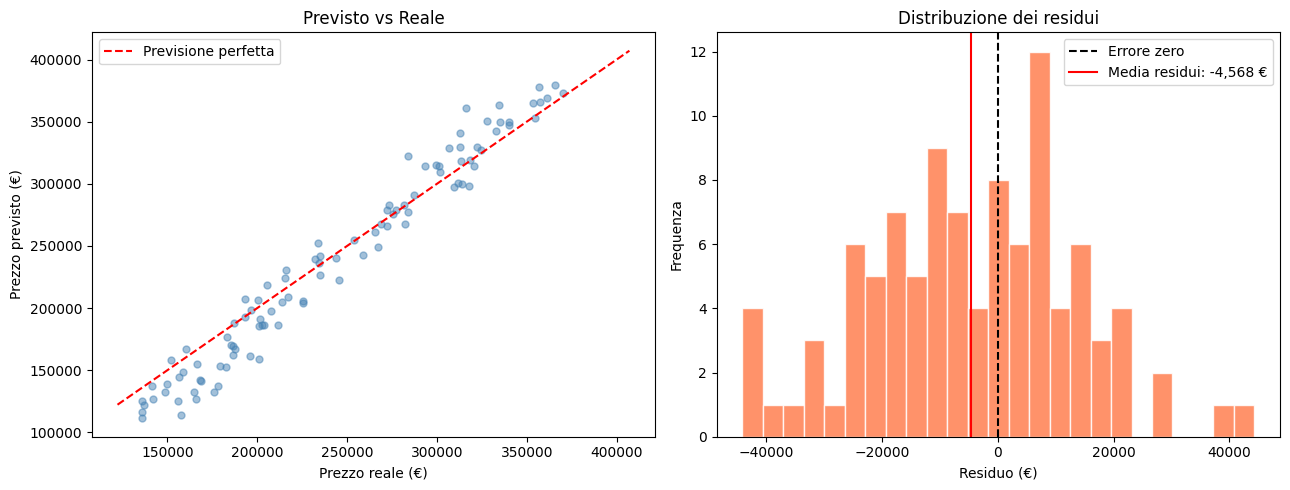

In [36]:
# Previsioni sul training set
y_pred_train = X @ w_fit + b_fit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico 1: previsto vs reale
ax = axes[0]
ax.scatter(y, y_pred_train, alpha=0.5, s=25, color='steelblue')
lim = [y.min() * 0.9, y.max() * 1.1]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Previsione perfetta')
ax.set_xlabel('Prezzo reale (€)')
ax.set_ylabel('Prezzo previsto (€)')
ax.set_title('Previsto vs Reale')
ax.legend()

# Grafico 2: distribuzione dei residui
# I residui (errori) di un buon modello devono essere:
# - centrati attorno allo zero (nessuna distorsione sistematica)
# - distribuiti in modo simmetrico
residuals = y_pred_train - y
ax2 = axes[1]
ax2.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Errore zero')
ax2.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5,
            label=f'Media residui: {residuals.mean():,.0f} €')
ax2.set_xlabel('Residuo (€)')
ax2.set_ylabel('Frequenza')
ax2.set_title('Distribuzione dei residui')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Implementazione con scikit-learn

Nella pratica non si implementa la discesa del gradiente a mano: scikit-learn lo fa internamente in modo ottimizzato.  
L'interfaccia è identica a quella vista per la regressione con una sola variabile: `fit()` e `predict()`.

In [37]:
# Con scikit-learn: LinearRegression usa internamente SVD (più stabile del GD)
model = LinearRegression()

# .fit() riceve la matrice X (m x n) e il vettore y (m,)
# Internamente trova i valori ottimali di w e b che minimizzano J
model.fit(X, y)

# I pesi trovati dal modello
# .coef_ -> vettore dei pesi [w1, w2, ..., wn]
# .intercept_ -> bias scalare b
print('Confronto scikit-learn vs GD da zero vs pesi veri:')
print(f'{"Feature":<12} {"sklearn":>12} {"GD da zero":>12} {"Vero":>10}')
for i, nome in enumerate(feature_names):
    print(f'{nome:<12} {model.coef_[i]:>12.1f} {w_fit[i]:>12.1f} {w_veri[i]:>10.1f}')
print(f'{"bias b":<12} {model.intercept_:>12.1f} {b_fit:>12.1f} {b_vero:>10.1f}')

Confronto scikit-learn vs GD da zero vs pesi veri:
Feature           sklearn   GD da zero       Vero
superficie         2028.9       2438.1     2000.0
stanze             5045.4       2042.0     5000.0
età                -350.2        364.3     -300.0
bias b            49381.5        500.9    50000.0


In [38]:
# scikit-learn trova i pesi veri quasi esattamente (la differenza è solo il rumore)
# perché usa SVD invece del GD, che è una soluzione esatta e non iterativa

# Previsioni con scikit-learn
y_pred_sklearn = model.predict(X_nuovi)

print('Previsioni su nuovi appartamenti con scikit-learn:')
for i, desc in enumerate(descrizioni):
    print(f'  {desc:<25} -> {y_pred_sklearn[i]:>10,.0f} €')

print()
# Score R^2: quanto bene il modello spiega la varianza del target
# 1.0 = perfetto, 0.0 = il modello non spiega nulla
r2 = model.score(X, y)
print(f'R^2 sul training set: {r2:.4f}')
print('Un R^2 vicino a 1 indica che il modello cattura bene la relazione tra le feature e il target.')

Previsioni su nuovi appartamenti con scikit-learn:
  80mq, 3 stanze, 10 anni   ->    223,326 €
  120mq, 4 stanze, 5 anni   ->    311,277 €
  50mq, 2 stanze, 30 anni   ->    150,411 €

R^2 sul training set: 0.9858
Un R^2 vicino a 1 indica che il modello cattura bene la relazione tra le feature e il target.


### 6.1 Interpretare i pesi

Ogni peso `W_j` indica quanto la j-esima feature influenza la previsione, **a parità di tutte le altre feature**.  
Un `W_j` grande in valore assoluto significa che quella feature conta molto. Un `W_j` vicino a zero significa che ha poco impatto.

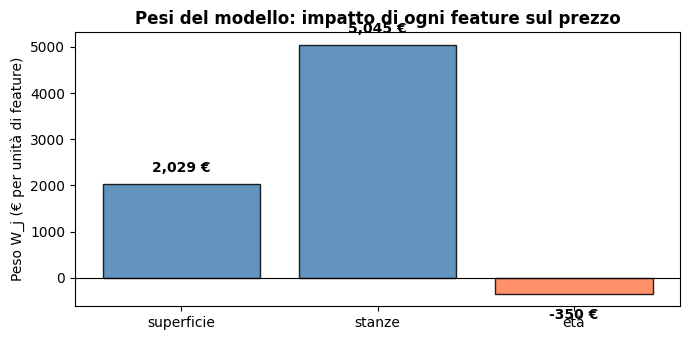

Interpretazione:
superficie: +2,029 € per ogni mq in più
stanze: +5,045 € per ogni stanza in più
età: -350 € per ogni anno in più (il segno negativo = più vecchio = meno valore)


In [39]:
# Visualizziamo i pesi trovati da scikit-learn
fig, ax = plt.subplots(figsize=(7, 3.5))

colors = ['steelblue' if c > 0 else 'coral' for c in model.coef_]
bars = ax.bar(feature_names, model.coef_, color=colors, edgecolor='black', alpha=0.85)

# Aggiungiamo il valore sopra ogni barra
for bar, val in zip(bars, model.coef_):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (200 if val > 0 else -600),
            f'{val:,.0f} €',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Peso W_j (€ per unità di feature)')
ax.set_title('Pesi del modello: impatto di ogni feature sul prezzo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretazione:')
print(f'superficie: +{model.coef_[0]:,.0f} € per ogni mq in più')
print(f'stanze: +{model.coef_[1]:,.0f} € per ogni stanza in più')
print(f'età: {model.coef_[2]:,.0f} € per ogni anno in più (il segno negativo = più vecchio = meno valore)')

### Passo successivo: Regressione Polinominale!